# 2.2 Shape

CuTe makes the observation that a 2D shape $(M, N)$ can also be interpreted to describe 1D $MN$ elements indexed
by an integral coordinate $i$ with $0 \le i < MN$ provided a bijection

$$S : \mathbb{Z}_{MN} \longleftrightarrow \mathbb{Z}_M \times \mathbb{Z}_N$$

maps between the 1D integral coordinates $i \in \mathbb{Z}_{MN}$ and the 2D natural coordinates $(m, n) \in \mathbb{Z}_M \times \mathbb{Z}_N$.

Similarly, the 2D shape $(M, NP)$ can be interpreted as a hierarchical shape $(M, (N, P))$ indexed by natural coordinates $(m, (n, p))$ with $0 \le m < M$, $0 \le n < N$, $0 \le p < P$. A similar bijection can be made

$$S : \mathbb{Z}_M \times \mathbb{Z}_{NP} \longleftrightarrow \mathbb{Z}_M \times (\mathbb{Z}_N \times \mathbb{Z}_P)$$

to map between the 2D coordinates $(m, q) \in \mathbb{Z}_M \times \mathbb{Z}_{NP}$ and the natural coordinates $(m, (n, p)) \in \mathbb{Z}_M \times (\mathbb{Z}_N \times \mathbb{Z}_P)$.

A direct consequence of hierarchical shapes and coordinates is that tensor algorithms can be written for the shapes that are most natural to them (Section 2.6) – 1D shapes for vectors in COPY, 2D shapes for matrices in GEMM, 3D shapes for tensors in batched-GEMM, etc – while still accepting hierarchically shaped tensors that are folded to be weakly congruent with the algorithm’s specification (Section 2.2.1). Tensors of data, whose shape is often represented as a flat sequence of integers, can be arbitrarily folded into shapes accepted by generic tensor algorithms. Furthermore, because each mode of a tensor is associated with a stride (Section 2.3) to index data, this folding of modes allows the representation of much more complex layouts of data beyond simple contiguous arrays in COPY or row-major and col-major matrices in BLAS GEMM (Section 2.4).

In the following sections, we define this notion of compatibility and these relations between coordinate sets within a shape.

In [1]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout

In [2]:
# Demonstrate the 1D <-> 2D bijection for shape (M, N)
L = Layout((3, 4))
print(f"Shape {L.shape} has {size(L)} elements.")
print(f"\n1D integral coordinates <-> 2D natural coordinates:")
for i in range(size(L)):
    crd = idx2crd(i, L)
    print(f"  i={i:2d}  <->  (m, n) = {crd}")


Shape (3, 4) has 12 elements.

1D integral coordinates <-> 2D natural coordinates:
  i= 0  <->  (m, n) = (0, 0)
  i= 1  <->  (m, n) = (1, 0)
  i= 2  <->  (m, n) = (2, 0)
  i= 3  <->  (m, n) = (0, 1)
  i= 4  <->  (m, n) = (1, 1)
  i= 5  <->  (m, n) = (2, 1)
  i= 6  <->  (m, n) = (0, 2)
  i= 7  <->  (m, n) = (1, 2)
  i= 8  <->  (m, n) = (2, 2)
  i= 9  <->  (m, n) = (0, 3)
  i=10  <->  (m, n) = (1, 3)
  i=11  <->  (m, n) = (2, 3)


In [3]:
# Hierarchical shape: (M, (N, P)) — the 2D shape (M, NP) refined
L = Layout((3, (2,4)))
print(f"Hierarchical shape {L.shape} has {size(L)} elements.")
print(f"\n2D coords (m, q) <-> natural coords (m, (n, p)):")
for i in range(size(L)):
    crd_2d = idx2crd(i, (size(mode(L,0)), size(mode(L,1))))
    crd_hier = idx2crd(i, L.shape)
    print(f"  (m, q) = {crd_2d}  <->  (m, (n, p)) = {crd_hier}")

Hierarchical shape (3, (2, 4)) has 24 elements.

2D coords (m, q) <-> natural coords (m, (n, p)):
  (m, q) = (0, 0)  <->  (m, (n, p)) = (0, (0, 0))
  (m, q) = (1, 0)  <->  (m, (n, p)) = (1, (0, 0))
  (m, q) = (2, 0)  <->  (m, (n, p)) = (2, (0, 0))
  (m, q) = (0, 1)  <->  (m, (n, p)) = (0, (1, 0))
  (m, q) = (1, 1)  <->  (m, (n, p)) = (1, (1, 0))
  (m, q) = (2, 1)  <->  (m, (n, p)) = (2, (1, 0))
  (m, q) = (0, 2)  <->  (m, (n, p)) = (0, (0, 1))
  (m, q) = (1, 2)  <->  (m, (n, p)) = (1, (0, 1))
  (m, q) = (2, 2)  <->  (m, (n, p)) = (2, (0, 1))
  (m, q) = (0, 3)  <->  (m, (n, p)) = (0, (1, 1))
  (m, q) = (1, 3)  <->  (m, (n, p)) = (1, (1, 1))
  (m, q) = (2, 3)  <->  (m, (n, p)) = (2, (1, 1))
  (m, q) = (0, 4)  <->  (m, (n, p)) = (0, (0, 2))
  (m, q) = (1, 4)  <->  (m, (n, p)) = (1, (0, 2))
  (m, q) = (2, 4)  <->  (m, (n, p)) = (2, (0, 2))
  (m, q) = (0, 5)  <->  (m, (n, p)) = (0, (1, 2))
  (m, q) = (1, 5)  <->  (m, (n, p)) = (1, (1, 2))
  (m, q) = (2, 5)  <->  (m, (n, p)) = (2, (1, 2))
  

## 2.2.1 Coordinate Sets and Compatibility

As previously suggested, hierarchical shapes provide for indexing by multiple coordinate systems. Here, we define the coordinate set for a specific shape and a notion of compatibility between shapes to share coordinate sets between shapes.

**Definition 2.6.** A *coordinate set* is a set $\mathbb{Z}_N = \{0, 1, 2, \ldots, N-1\}$ of non-negative integers or a Cartesian product of coordinate sets, $\mathbb{Z}_N \times \mathbb{Z}_M = \mathbb{Z}_{(N,M)}$.

For instance, the following are examples of coordinate sets:

$$\mathbb{Z}_6 = \{0, 1, 2, 3, 4, 5\}$$

$$\mathbb{Z}_3 \times \mathbb{Z}_4 = \mathbb{Z}_{(3,4)} = \{(0,0), (1,0), (2,0), (0,1), (1,1), (2,1), (0,2), (1,2), (2,2), (0,3), (1,3), (2,3)\}$$

$$(\mathbb{Z}_2 \times \mathbb{Z}_1) \times \mathbb{Z}_3 = \mathbb{Z}_{((2,1),3)} = \{((0,0),0), ((1,0),0), ((0,0),1), ((1,0),1), ((0,0),2), ((1,0),2)\}$$

In [4]:
def coord_set(shape):
    """Generate the coordinate set Z_S for a given shape, in colexicographic order."""
    return [idx2crd(i, shape) for i in range(size(shape))]
    
print("Z_6 =", coord_set(6))
print()
print("Z_(3,4) =", coord_set((3, 4)))
print()
print("Z_((2,1),3) =", coord_set(((2, 1), 3)))

Z_6 = [0, 1, 2, 3, 4, 5]

Z_(3,4) = [(0, 0), (1, 0), (2, 0), (0, 1), (1, 1), (2, 1), (0, 2), (1, 2), (2, 2), (0, 3), (1, 3), (2, 3)]

Z_((2,1),3) = [((0, 0), 0), ((1, 0), 0), ((0, 0), 1), ((1, 0), 1), ((0, 0), 2), ((1, 0), 2)]


A coordinate set $\mathbb{Z}_S$ is precisely the set of natural coordinates for a shape $S$. Other coordinate sets for a shape $S$ are any coordinate set for a shape that is compatible with $S$ and coarsens $S$.

**Definition 2.7.** *Compatibility*, $\preceq$, is a partial order on the set of shapes. For shapes $P$ and $S$,

$$P \preceq S \quad \text{iff} \quad P \in \mathbb{Z}^+ \text{ and } P = |S|, \quad \text{or} \quad P, S \in \text{Tuple and } \text{rank}(P) = \text{rank}(S) \text{ and } \forall i\ P_i \preceq S_i$$

and we say that $P$ and $S$ are *compatible*, $P$ *coarsens* $S$, and $S$ *refines* $P$.

Compatibility requires that the two shapes be the same size, so the integral values of the HTuples matter. For example,

$$30 \preceq (2, 15) \preceq (2, (3, 5))$$

and

$$30 \preceq (6, 5) \preceq ((3, 2), 5)$$

but $(2, (3, 5))$ and $((3, 2), 5)$ are *not* compatible despite having the same size. They do, however, share a common compatible shape of $30$.

In [5]:
# 30 ⪯ (2, 15) ⪯ (2, (3, 5))
print(f'30 ⪯ (2, 15):       {compatible(30, (2, 15))}')
print(f'(2, 15) ⪯ (2, (3,5)): {compatible((2, 15), (2, (3, 5)))}')
print(f'30 ⪯ (2, (3, 5)):   {compatible(30, (2, (3, 5)))}')
print()

# 30 ⪯ (6, 5) ⪯ ((3, 2), 5)
print(f'30 ⪯ (6, 5):        {compatible(30, (6, 5))}')
print(f'(6, 5) ⪯ ((3,2),5): {compatible((6, 5), ((3, 2), 5))}')
print()

# (2, (3, 5)) and ((3, 2), 5) are NOT compatible
print(f'(2,(3,5)) ⪯ ((3,2),5): {compatible((2, (3, 5)), ((3, 2), 5))}')
print(f'((3,2),5) ⪯ (2,(3,5)): {compatible(((3, 2), 5), (2, (3, 5)))}')
print("Both have size 30, but they are not compatible.")

30 ⪯ (2, 15):       True
(2, 15) ⪯ (2, (3,5)): True
30 ⪯ (2, (3, 5)):   True

30 ⪯ (6, 5):        True
(6, 5) ⪯ ((3,2),5): True

(2,(3,5)) ⪯ ((3,2),5): False
((3,2),5) ⪯ (2,(3,5)): False
Both have size 30, but they are not compatible.


With the definition of a coordinate set and shape compatibility, we can define the set of all compatible coordinates for any given shape.

**Definition 2.8.** A shape $S$ defines a set of compatible coordinate sets, $\mathcal{Z}(S)$, as the coordinate sets of all shapes that coarsen $S$.

$$\mathcal{Z}(S) = \{\mathbb{Z}_{S'} \mid S' \preceq S\}. \qquad (3)$$

Every shape has an integral coordinate set,

$$\{0, 1, 2, \ldots, |S|-1\} = \mathbb{Z}_{|S|} \in \mathcal{Z}(S),$$

and every rank-$r$ shape has a rank-$r$ coordinate set,

$$\{(a_0, \ldots, a_{r-1}) \mid a_i \in \mathbb{Z}_{|S_i|}\} = \mathbb{Z}_{(|S_0|,|S_1|,\ldots,|S_{r-1}|)} \in \mathcal{Z}(S).$$

Note that if shape $P$ coarsens shape $S$, then $\mathcal{Z}(P) \subseteq \mathcal{Z}(S)$. This means that any coordinate within shape $P$ is also a coordinate within shape $S$.

## 2.2.2 Coordinates

In this section, we define classes of coordinates, define a bijection between the compatible coordinate sets of a shape, and provide examples of these coordinate mappings.

**Definition 2.9.** An *in-bounds coordinate*, or simply *coordinate*, into a shape $S$ is an element of one of its coordinate sets, $c \in \mathbb{Z}_{S'} \in \mathcal{Z}(S)$. Note that a coordinate is always an HTuple($\mathbb{N}$). When intention is clear, we will simply write $c \in \mathcal{Z}(S)$.

**Definition 2.10.** An *integral coordinate* into a shape $S$ is a coordinate $c \in \mathbb{Z}_{|S|} \in \mathcal{Z}(S)$. Note that an integral coordinate is always an integer, $c \in \mathbb{N}$.

**Definition 2.11.** A *natural coordinate* into a shape $S$ is a coordinate $\tilde{c} \in \mathbb{Z}_S \in \mathcal{Z}(S)$. Note that a natural coordinate is always an HTuple($\mathbb{N}$) that is congruent to the shape, $\tilde{c} \sim S$.

To transform between in-bound coordinates, we construct an enumeration over the coordinate sets of a shape $S$ to define coordinate lists. In this work, we choose the colexicographical ordering, $<$, of coordinates defined by:

$$(a_0, \ldots, a_n) < (b_0, \ldots, b_n) \quad \text{iff} \quad a_n < b_n, \quad \text{or} \quad a_n = b_n \text{ and } (a_0, \ldots, a_{n-1}) < (b_0, \ldots, b_{n-1})$$

and applied recursively as needed. The colexicographical enumeration defines a bijection on coordinate lists. The function

$$\text{idx2crd}: \mathbb{Z}_{|S|} \to \mathbb{Z}_{(|S_0|, |S_1|, \ldots, |S_{r-1}|)},$$

$$i \mapsto \left(i \bmod |S_0|,\ \left\lfloor \frac{i}{|S_0|} \right\rfloor \bmod |S_1|,\ \ldots,\ \left\lfloor \frac{i}{\prod_{k=0}^{r-2} |S_k|} \right\rfloor \right) \qquad (4)$$

maps the $i\mathrm{th}$ coordinate of $\mathbb{Z}_{|S|}$ (the $i\mathrm{th}$ integral coordinate of shape $S$) to the $i\mathrm{th}$ coordinate of $\mathbb{Z}_{(|S_0|,|S_1|,\ldots,|S_{r-1}|)}$ (the $i\mathrm{th}$ natural coordinate of shape $(|S_0|, |S_1|, \ldots, |S_{r-1}|)$).

The inverse of idx2crd is given by

$$\text{crd2idx}: \mathbb{Z}_{(|S_0|,|S_1|,\ldots,|S_{r-1}|)} \to \mathbb{Z}_{|S|},$$

$$( c_0, c_1, \ldots, c_{r-1}) \mapsto c_0 + c_1 \cdot |S_0| + \ldots + c_{r-1} \cdot \prod_{k=0}^{r-2} |S_k| \qquad (5)$$

which maps the $i\mathrm{th}$ coordinate of $\mathbb{Z}_{(|S_0|,|S_1|,\ldots,|S_{r-1}|)}$ to the $i\mathrm{th}$ coordinate of $\mathbb{Z}_{|S|}$.

In [6]:
# Figure 2: Coordinate sets for three example shapes

# S = 4
print("S = 4")
print("Z(S) = {Z_4}")
print("Z_4:", coord_set(4))
print()

# S = (2, 3)
print("S = (2, 3)")
print("Z(S) = {Z_6, Z_(2,3)}")
print("Z_6:    ", coord_set(6))
print("Z_(2,3):", coord_set((2, 3)))
for i in range(size(S)):
    crd = idx2crd(i, S.shape)
    print(f"{i:4d}   {str(crd):>10s}")
print()

# S = ((2, 3), 2)
print("S = ((2, 3), 2)")
print("Z(S) = {Z_12, Z_(6,2), Z_((2,3),2)}")
print("Z_12:        ", coord_set(12))
print("Z_(6,2):     ", coord_set((6, 2)))
print("Z_((2,3),2): ", coord_set(((2, 3), 2)))
for i in range(size(S)):
    crd_flat = idx2crd(i, (6, 2))
    crd_nat = idx2crd(i, S.shape)
    print(f"{i:4d}   {str(crd_flat):>10s}   {str(crd_nat):>16s}")

S = 4
Z(S) = {Z_4}
Z_4: [0, 1, 2, 3]

S = (2, 3)
Z(S) = {Z_6, Z_(2,3)}
Z_6:     [0, 1, 2, 3, 4, 5]
Z_(2,3): [(0, 0), (1, 0), (0, 1), (1, 1), (0, 2), (1, 2)]


NameError: name 'S' is not defined

Layout ((2, 3), 2) : ((1, 2), 6) — 2D view


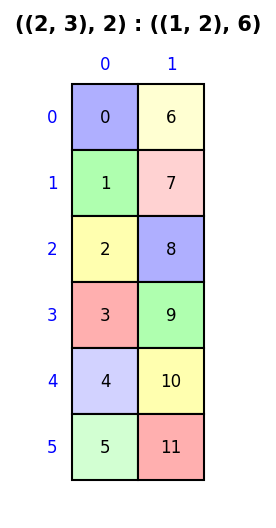

In [ ]:
# Visualize the layout to see the coordinate-to-offset mapping
print(f"Layout {layout} — 2D view")
draw_layout(layout, colorize=True)

### Out-of-bounds Coordinates

In addition to the coordinate sets we have already defined, it is useful to define coordinates of specific profiles that may not be in the coordinate sets of a shape.

**Definition 2.12.** An *admissible coordinate* into a shape $S$ is any coordinate $c \in \text{HTuple}(\mathbb{Z})$ that is weakly congruent to the shape, $c \lesssim S$.

**Definition 2.13.** An *out-of-bounds coordinate* into a shape $S$ is any admissible coordinate $c \in \text{HTuple}(\mathbb{Z})$ that is not in-bounds, $c \notin \mathcal{Z}(S)$.

**Definition 2.14.** A *congruent coordinate* into a shape $S$ is any coordinate $c \in \text{HTuple}(\mathbb{Z})$ that is congruent to the shape, $c \sim S$. This is denoted as $\overline{\mathbb{Z}}_S = \{c \in \text{HTuple}(\mathbb{Z}) \mid c \sim S\}$.

Note that `idx2crd` is well-defined for all integers, equivalently coordinates in $\overline{\mathbb{Z}}_{|S|}$, rather than simply the integers in $\mathbb{Z}_{|S|}$. When it is evaluated on an integer $i \ge |S|$, it will always return a coordinate $(c_0, c_1, \ldots, c_{r-1})$ that is out-of-bounds with respect to shape $(|S_0|, |S_1|, \ldots, |S_{r-1}|)$. In contrast, `crd2idx` cannot guarantee an out-of-bounds result for an out-of-bounds coordinate input. Therefore, `crd2idx` and `idx2crd` are only inverses of each other when evaluated on in-bounds coordinates.

In [ ]:
# idx2crd is well-defined for out-of-bounds integers
shape = (2, 3)
print(f"Shape: {shape}, size = {size(shape)}")
print()
print("In-bounds and out-of-bounds idx2crd:")
for i in range(10):
    crd = idx2crd(i, shape)
    back = crd2idx(crd, shape)
    in_bounds = i < size(shape)
    round_trips = (back == i)
    print(f"  i={i}: idx2crd -> {crd}, crd2idx -> {back}  "
          f"{'[in-bounds]' if in_bounds else '[OUT-OF-BOUNDS]'}  "
          f"{'round-trips' if round_trips else 'NO round-trip'}")

print()
# Show that crd2idx does NOT guarantee out-of-bounds for out-of-bounds input
oob_coord = (0, 3)  # out-of-bounds for shape (2, 3): n=3 >= 3
result = crd2idx(oob_coord, shape)
print(f"crd2idx({oob_coord}, {shape}) = {result}")
print(f"  This maps to {result}, which is IN the range [0, {size(shape)}),")
print(f"  even though {oob_coord} is out-of-bounds for shape {shape}.")
print(f"  idx2crd({result}, {shape}) = {idx2crd(result, shape)} != {oob_coord}")
print("  So crd2idx and idx2crd are NOT inverses on out-of-bounds coordinates.")

Shape: (2, 3), size = 6

In-bounds and out-of-bounds idx2crd:
  i=0: idx2crd -> (0, 0), crd2idx -> 0  [in-bounds]  round-trips
  i=1: idx2crd -> (1, 0), crd2idx -> 1  [in-bounds]  round-trips
  i=2: idx2crd -> (0, 1), crd2idx -> 2  [in-bounds]  round-trips
  i=3: idx2crd -> (1, 1), crd2idx -> 3  [in-bounds]  round-trips
  i=4: idx2crd -> (0, 2), crd2idx -> 4  [in-bounds]  round-trips
  i=5: idx2crd -> (1, 2), crd2idx -> 5  [in-bounds]  round-trips
  i=6: idx2crd -> (0, 0), crd2idx -> 0  [OUT-OF-BOUNDS]  NO round-trip
  i=7: idx2crd -> (1, 0), crd2idx -> 1  [OUT-OF-BOUNDS]  NO round-trip
  i=8: idx2crd -> (0, 1), crd2idx -> 2  [OUT-OF-BOUNDS]  NO round-trip
  i=9: idx2crd -> (1, 1), crd2idx -> 3  [OUT-OF-BOUNDS]  NO round-trip

crd2idx((0, 3), (2, 3)) = 6
  This maps to 6, which is IN the range [0, 6),
  even though (0, 3) is out-of-bounds for shape (2, 3).
  idx2crd(6, (2, 3)) = (0, 0) != (0, 3)
  So crd2idx and idx2crd are NOT inverses on out-of-bounds coordinates.
